# 动量因子 - 行业分类回测分析

本notebook展示如何按行业分类进行回测分析，帮助理解因子在不同行业的表现差异。

## 回测规则
- **买入时机**: T日收盘计算因子，T+1日开盘价买入
- **卖出时机**: T日收盘计算因子，T+1日开盘价卖出
- **持仓周期**: 根据因子信号决定，最长不超过max_holding_days

## 0. 导入依赖

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys

# 添加上级目录到路径
sys.path.append('/home/day_strategy/factors')
from utils.factor_utils import (
    load_all_symbols, load_symbol, get_all_categories,
    get_symbol_category, load_symbols_by_category,
    normalize_factor, analyze_factor_distribution,
    analyze_factor_ic, analyze_backtest_results
)

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['Noto Sans CJK SC', 'WenQuanYi Micro Hei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print('依赖导入完成')

依赖导入完成


## 1. 定义动量因子

在这里定义你的因子计算逻辑。因子值将在每天收盘后计算，用于预测未来收益。

In [2]:
# ==================== 因子参数配置 ====================
FACTOR_PARAMS = {
    'lookback': 20,  # 回看周期：计算过去N天的收益率
}

# ==================== 回测参数配置 ====================
ENTRY_THRESHOLD = 0.5   # 入场阈值：因子值超过此阈值时开仓
EXIT_THRESHOLD = 0.0    # 出场阈值：因子值回归此范围时平仓
MAX_HOLDING_DAYS = 20   # 最大持仓天数：强制平仓


def calculate_momentum_factor(df, lookback=20):
    """
    计算动量因子
    
    逻辑：计算过去lookback天的收益率，并进行标准化
    因子值越大，表示近期涨幅越大， momentum越强
    
    Parameters:
    -----------
    df : pd.DataFrame
        包含价格数据的DataFrame，需有'close'列
    lookback : int
        回看周期
    
    Returns:
    --------
    pd.Series
        动量因子值，与df长度相同
    """
    # 计算收益率
    returns = df['close'].pct_change(lookback)
    
    # 标准化（z-score）：使因子分布稳定
    factor = (returns - returns.rolling(lookback*2).mean()) / returns.rolling(lookback*2).std()
    
    return factor


print('✓ 动量因子定义完成')
print(f"  参数: lookback={FACTOR_PARAMS['lookback']}")
print(f"  入场阈值: {ENTRY_THRESHOLD}")
print(f"  出场阈值: {EXIT_THRESHOLD}")
print(f"  最大持仓: {MAX_HOLDING_DAYS}天")

✓ 动量因子定义完成
  参数: lookback=20
  入场阈值: 0.5
  出场阈值: 0.0
  最大持仓: 20天


## 2. 因子分布分析

分析因子的统计特征，确保因子分布合理：
- 时间序列稳定性
- 分布形态（是否接近正态）
- 异常值检测

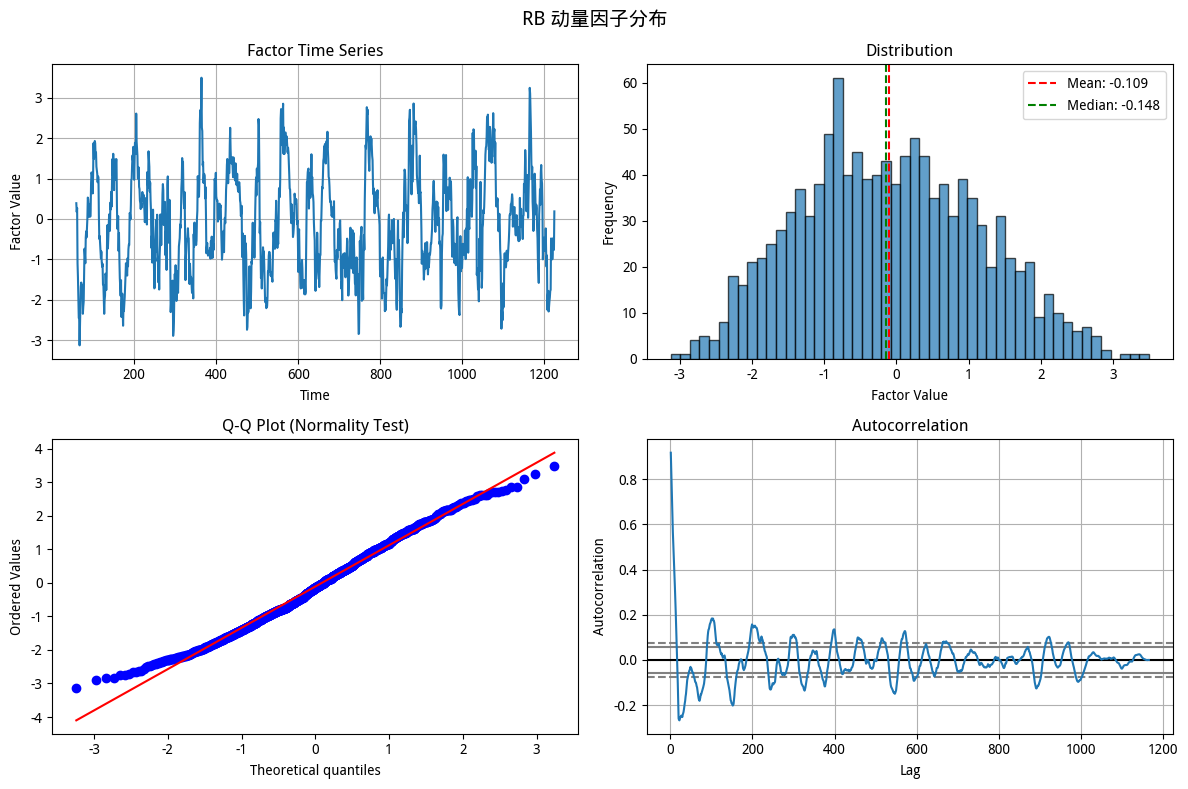


因子分布统计: RB 动量因子分布
样本数: 1166
均值: -0.1091
标准差: 1.2333
偏度: 0.1609
峰度: -0.5773
最小值: -3.1268
最大值: 3.4966
中位数: -0.1482
25%分位数: -1.0055
75%分位数: 0.7852



In [4]:
# 加载一个示例品种进行因子分布分析
symbol = 'RB'  # 螺纹钢
df = load_symbol(symbol)

# 计算因子
factor = calculate_momentum_factor(df, **FACTOR_PARAMS)

# 分析因子分布
analyze_factor_distribution(factor, title=f"{symbol} 动量因子分布")

### 📊 因子分布解读

**图1：时间序列**
- 观察因子是否随时间漂移（均值变化）
- 检查是否存在结构性变化

**图2：分布直方图**
- 理想情况下应接近正态分布
- 偏度(Skewness)：>0右偏，<0左偏
- 峰度(Kurtosis)：>3厚尾，<3薄尾

**图3：Q-Q图**
- 检验正态性，点越接近直线越正态

**图4：自相关**
- 因子是否自相关影响交易频率
- 高自相关意味着信号持续性强

## 3. 因子评价（IC分析）

分析因子的预测能力：
- **IC (Information Coefficient)**: 因子值与未来收益的相关系数
- **Rank IC**: 因子排名与未来收益排名的相关系数
- **IR (Information Ratio)**: IC的稳定性指标

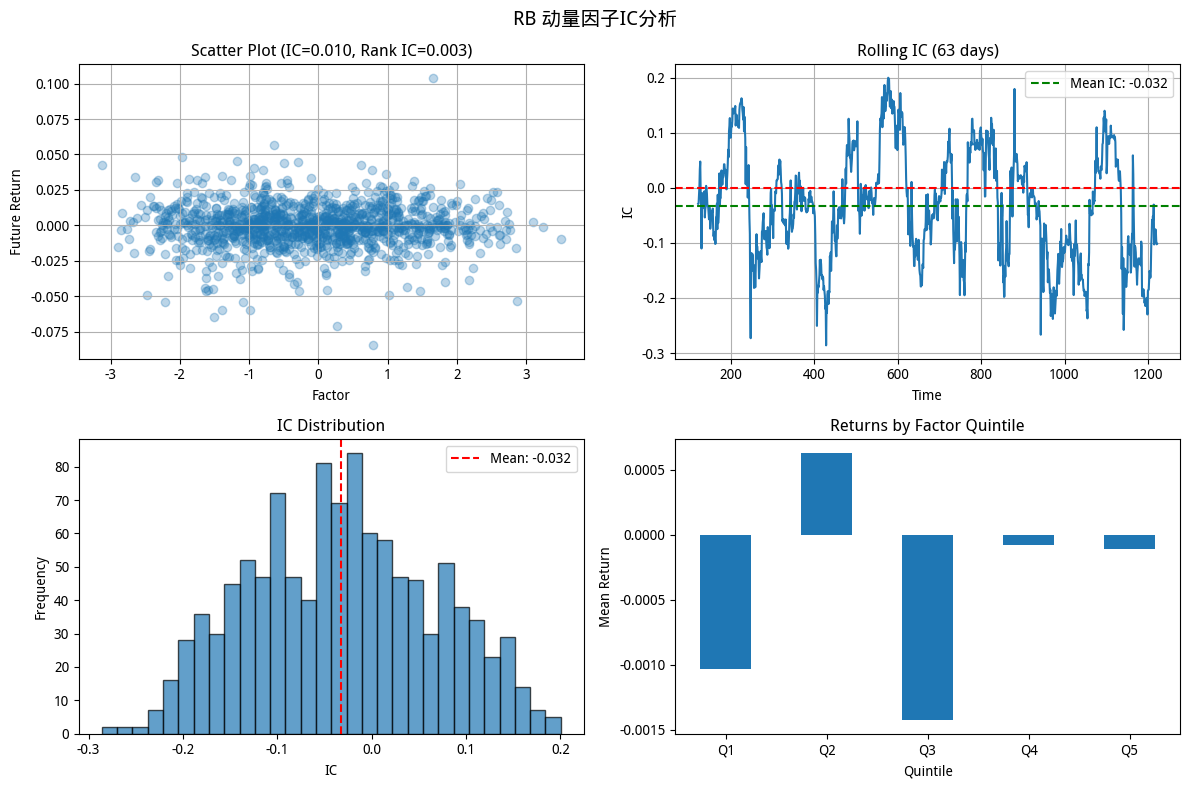


因子IC分析: RB 动量因子IC分析
IC (Pearson): 0.0097
Rank IC (Spearman): 0.0028
IC均值: -0.0324
IC标准差: 0.0980
IR (IC/Std): -0.3306
IC>0比例: 33.93%



In [5]:
# 计算未来收益（T+1 open买入，T+2 open卖出）
# 即：未来收益率 = (T+2 open - T+1 open) / T+1 open
future_return = df['open'].shift(-2) / df['open'].shift(-1) - 1

# 分析因子IC
ic, rank_ic = analyze_factor_ic(factor, future_return, title=f"{symbol} 动量因子IC分析")

### 📊 IC分析解读

**图1：因子vs收益散点图**
- 正相关：因子值越大，未来收益越高 → 因子有效
- 负相关：因子值越大，未来收益越低 → 反向因子有效
- 无相关：因子无效

**图2：滚动IC**
- 观察IC是否稳定，是否存在周期性
- IC均值 > 0.03 表示因子有一定预测能力

**图3：IC分布**
- IC>0的比例应显著大于50%

**图4：分组收益**
- Q5（因子最高组）应明显跑赢Q1（因子最低组）
- 单调性：Q1<Q2<Q3<Q4<Q5 说明因子单调有效

## 4. 回测分析

使用第二天open买入、第三天open卖出的规则进行回测：
- 信号产生：T日收盘计算因子
- 开仓：T+1日开盘价
- 平仓：T+2日开盘价（或根据信号提前平仓）

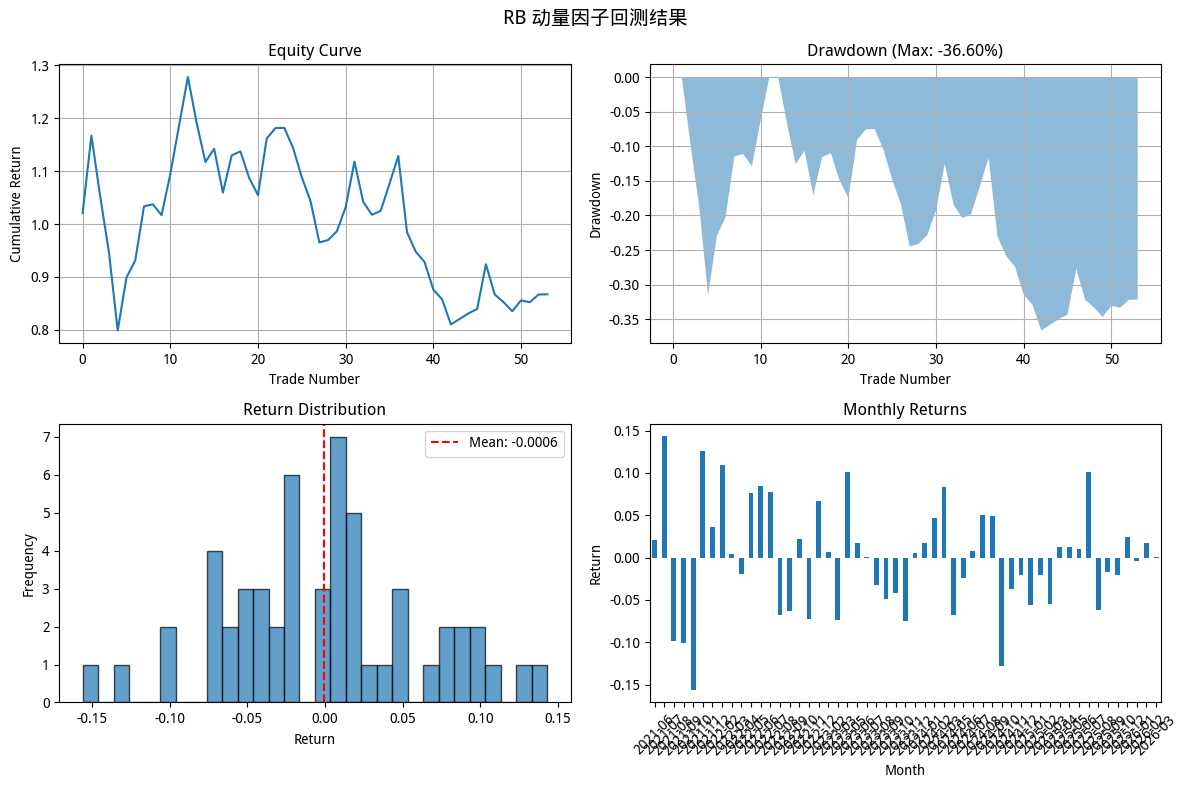


回测结果: RB 动量因子回测结果
总交易次数: 54
胜率: 53.70%
平均收益: -0.0006
夏普比率: -0.16
最大回撤: -36.60%
总收益: -13.28%



In [6]:
def backtest_open_to_open(df, factor, entry_threshold=0.5, exit_threshold=0.0, max_holding_days=20):
    """
    回测：第二天open买入，第三天open卖出
    
    交易规则：
    - T日收盘计算因子
    - T+1日open开仓
    - T+2日open平仓（或根据信号提前平仓）
    """
    df = df.copy()
    df['factor'] = factor.values
    df = df.reset_index(drop=True)
    
    trades = []
    position = 0  # 0:无持仓, 1:多头, -1:空头
    entry_idx = None
    entry_price = None
    holding_days = 0
    
    for i in range(len(df) - 2):
        current_factor = df.loc[i, 'factor']
        
        if pd.isna(current_factor):
            continue
        
        # 开仓逻辑
        if position == 0:
            if current_factor > entry_threshold:
                # 多头开仓：T+1 open买入
                position = 1
                entry_idx = i
                entry_price = df.loc[i + 1, 'open']
                holding_days = 0
            elif current_factor < -entry_threshold:
                # 空头开仓：T+1 open卖出（做空）
                position = -1
                entry_idx = i
                entry_price = df.loc[i + 1, 'open']
                holding_days = 0
        
        # 持仓逻辑
        else:
            holding_days += 1
            exit_flag = False
            
            # 出场条件1：因子回归
            if abs(current_factor) <= exit_threshold:
                exit_flag = True
            
            # 出场条件2：达到最大持仓天数
            if holding_days >= max_holding_days:
                exit_flag = True
            
            # 出场条件3：数据结束
            if i >= len(df) - 3:
                exit_flag = True
            
            if exit_flag:
                # T+1 open平仓
                exit_price = df.loc[i + 1, 'open']
                
                # 计算收益
                if position == 1:
                    pnl = (exit_price - entry_price) / entry_price
                else:
                    pnl = (entry_price - exit_price) / entry_price
                
                # 扣除手续费（双边万2）
                pnl = pnl - 0.0002
                
                trades.append({
                    'entry_date': df.loc[entry_idx, 'trade_date'],
                    'exit_date': df.loc[i, 'trade_date'],
                    'direction': 'long' if position == 1 else 'short',
                    'holding_days': holding_days,
                    'pnl': pnl,
                    'entry_factor': df.loc[entry_idx, 'factor'],
                    'exit_factor': current_factor,
                    'entry_price': entry_price,
                    'exit_price': exit_price
                })
                
                position = 0
                entry_idx = None
                holding_days = 0
    
    return pd.DataFrame(trades)


# 运行回测
trades = backtest_open_to_open(
    df, factor,
    entry_threshold=ENTRY_THRESHOLD,
    exit_threshold=EXIT_THRESHOLD,
    max_holding_days=MAX_HOLDING_DAYS
)

# 分析回测结果
analyze_backtest_results(trades, title=f"{symbol} 动量因子回测结果")

### 📊 回测结果解读

**图1：权益曲线**
- 长期向上说明策略有效
- 曲线平滑度反映风险

**图2：回撤**
- 最大回撤反映最坏情况
- 回撤恢复时间反映策略韧性

**图3：收益分布**
- 正偏度：小亏大赚
- 负偏度：小赚大亏

**图4：月度收益**
- 观察是否有季节性规律
- 连续亏损月份数量

## 5. 分行业回测分析

遍历所有行业，分别回测，对比不同行业的表现差异。

In [7]:
def run_category_backtest(factor_func, factor_kwargs,
                          entry_threshold=0.5,
                          exit_threshold=0.0,
                          max_holding_days=20):
    """
    按行业运行回测
    """
    category_results = {}
    
    for category in get_all_categories():
        print(f"\n{'='*60}")
        print(f"回测行业: {category}")
        print(f"{'='*60}")
        
        symbols_data = load_symbols_by_category(category)
        if not symbols_data:
            print(f"  {category}: 无数据")
            continue
        
        all_trades = []
        for symbol, df in symbols_data.items():
            try:
                factor = factor_func(df, **factor_kwargs)
                trades = backtest_open_to_open(
                    df, factor,
                    entry_threshold=entry_threshold,
                    exit_threshold=exit_threshold,
                    max_holding_days=max_holding_days
                )
                if len(trades) > 0:
                    trades['symbol'] = symbol
                    all_trades.append(trades)
            except Exception as e:
                print(f"  Error in {symbol}: {e}")
        
        if all_trades:
            category_results[category] = pd.concat(all_trades, ignore_index=True)
            print(f"  {category}: {len(category_results[category])} 笔交易")
        else:
            print(f"  {category}: 无交易")
    
    return category_results


# 运行行业回测
category_results = run_category_backtest(
    factor_func=calculate_momentum_factor,
    factor_kwargs=FACTOR_PARAMS,
    entry_threshold=ENTRY_THRESHOLD,
    exit_threshold=EXIT_THRESHOLD,
    max_holding_days=MAX_HOLDING_DAYS
)

print(f"\n{'='*60}")
print(f"成功回测 {len(category_results)} 个行业")
print(f"{'='*60}")


回测行业: 原油
  原油: 无数据

回测行业: 黑色金属
  黑色金属: 374 笔交易

回测行业: 化工
  化工: 732 笔交易

回测行业: 煤炭
  煤炭: 无数据

回测行业: 轻工
  轻工: 无数据

回测行业: 有色金属
  有色金属: 418 笔交易

回测行业: 贵金属
  贵金属: 109 笔交易

回测行业: 谷物
  谷物: 54 笔交易

回测行业: 农副
  农副: 无数据

回测行业: 软商品
  软商品: 无数据

回测行业: 油脂油料
  油脂油料: 376 笔交易

回测行业: 航运
  航运: 无数据

成功回测 6 个行业


## 6. 行业权益曲线对比

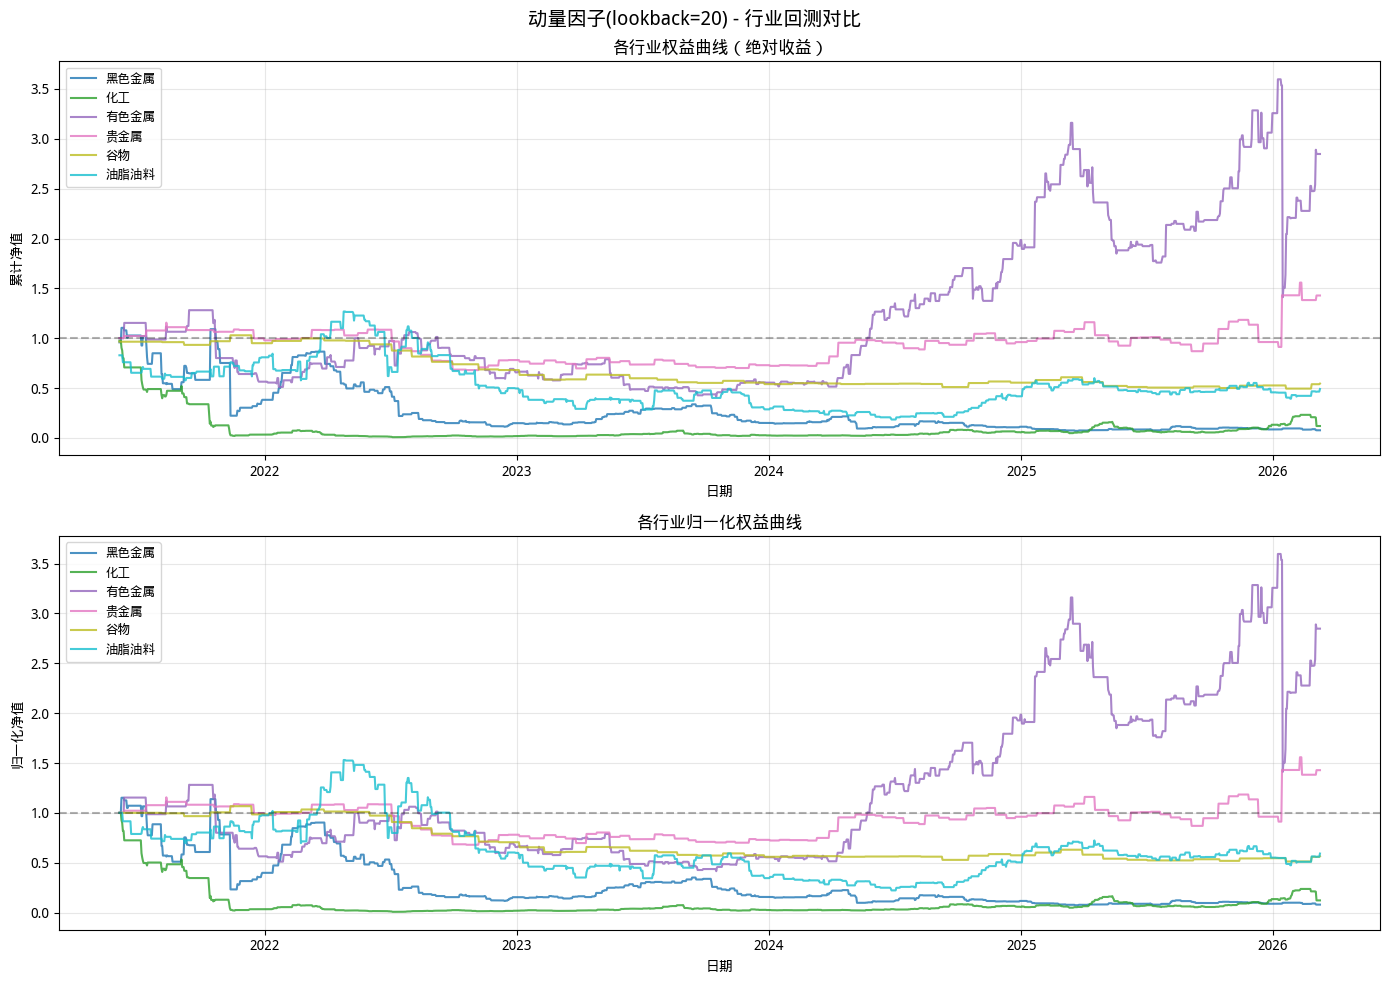


各行业回测绩效对比（按夏普排序）
  行业       总收益      夏普比率      最大回撤  交易次数
有色金属  1.847958  1.336750 -0.676484   418
 贵金属  0.428349  1.216757 -0.411741   109
油脂油料 -0.509628  0.136788 -0.854735   376
  化工 -0.881020  0.056656 -0.992772   732
黑色金属 -0.923725 -0.432987 -0.936232   374
  谷物 -0.455364 -3.779186 -0.519780    54


In [8]:
def plot_category_comparison(category_results, title="行业回测对比"):
    """
    绘制各行业权益曲线对比
    """
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    fig.suptitle(title, fontsize=14, fontweight='bold')
    
    # 准备数据
    category_daily_returns = {}
    all_dates = set()
    
    for category, trades in category_results.items():
        if len(trades) == 0:
            continue
        
        trades['exit_date'] = pd.to_datetime(trades['exit_date'])
        daily = trades.groupby('exit_date')['pnl'].sum()
        category_daily_returns[category] = daily
        all_dates.update(daily.index)
    
    if not category_daily_returns:
        print("无数据可绘制")
        return
    
    date_range = pd.date_range(start=min(all_dates), end=max(all_dates), freq='D')
    colors = plt.cm.tab10(np.linspace(0, 1, len(category_daily_returns)))
    
    # 图1：绝对权益曲线
    ax1 = axes[0]
    category_stats = []
    
    for i, (category, daily) in enumerate(category_daily_returns.items()):
        daily_aligned = daily.reindex(date_range, fill_value=0)
        equity = (1 + daily_aligned).cumprod()
        
        ax1.plot(equity.index, equity.values, label=category,
                color=colors[i], linewidth=1.5, alpha=0.8)
        
        # 统计
        total_return = equity.iloc[-1] - 1
        sharpe = daily.mean() / daily.std() * np.sqrt(252) if daily.std() > 0 else 0
        max_dd = (equity / equity.cummax() - 1).min()
        category_stats.append({
            '行业': category,
            '总收益': total_return,
            '夏普比率': sharpe,
            '最大回撤': max_dd,
            '交易次数': len(category_results[category])
        })
    
    ax1.axhline(1, color='black', linestyle='--', alpha=0.3)
    ax1.set_title('各行业权益曲线（绝对收益）', fontsize=12)
    ax1.set_xlabel('日期')
    ax1.set_ylabel('累计净值')
    ax1.legend(loc='upper left', fontsize=9)
    ax1.grid(True, alpha=0.3)
    
    # 图2：归一化权益曲线
    ax2 = axes[1]
    for i, (category, daily) in enumerate(category_daily_returns.items()):
        daily_aligned = daily.reindex(date_range, fill_value=0)
        equity = (1 + daily_aligned).cumprod()
        normalized = equity / equity.iloc[0]
        ax2.plot(normalized.index, normalized.values, label=category,
                color=colors[i], linewidth=1.5, alpha=0.8)
    
    ax2.axhline(1, color='black', linestyle='--', alpha=0.3)
    ax2.set_title('各行业归一化权益曲线', fontsize=12)
    ax2.set_xlabel('日期')
    ax2.set_ylabel('归一化净值')
    ax2.legend(loc='upper left', fontsize=9)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 打印统计表
    stats_df = pd.DataFrame(category_stats)
    stats_df = stats_df.sort_values('夏普比率', ascending=False)
    
    print(f"\n{'='*80}")
    print("各行业回测绩效对比（按夏普排序）")
    print(f"{'='*80}")
    print(stats_df.to_string(index=False))
    print(f"{'='*80}")
    
    return stats_df


# 绘制行业对比图
stats_df = plot_category_comparison(category_results, title=f"动量因子(lookback={FACTOR_PARAMS['lookback']}) - 行业回测对比")

### 📊 行业权益曲线解读

**图1：绝对权益曲线**
- **斜率**: 斜率越大收益越高
- **平滑度**: 波动小的行业策略更稳定
- **同涨同跌**: 多条曲线同时涨跌说明行业相关性高

**图2：归一化权益曲线**
- 所有曲线从1开始，便于比较相对走势
- 可以清楚看到哪些行业在特定时期跑赢/跑输
- 帮助识别行业的周期性特征

## 7. 行业绩效指标对比

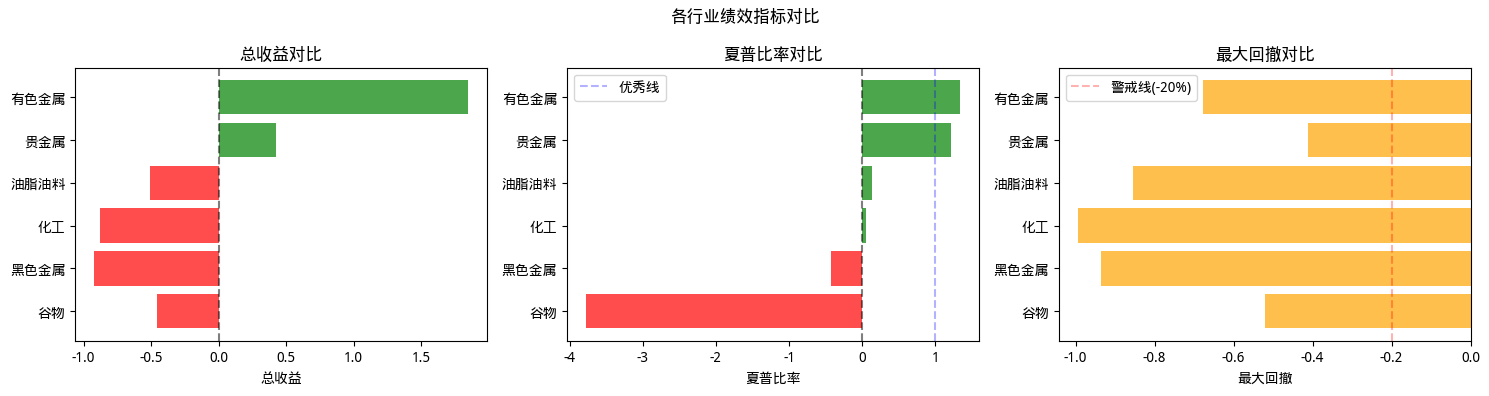

In [9]:
# 绘制行业绩效指标对比图
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('各行业绩效指标对比', fontsize=12, fontweight='bold')

# 按夏普排序
stats_sorted = stats_df.sort_values('夏普比率', ascending=True)

# 总收益
colors = ['green' if x > 0 else 'red' for x in stats_sorted['总收益']]
axes[0].barh(stats_sorted['行业'], stats_sorted['总收益'], color=colors, alpha=0.7)
axes[0].set_xlabel('总收益')
axes[0].set_title('总收益对比')
axes[0].axvline(0, color='black', linestyle='--', alpha=0.5)

# 夏普比率
colors = ['green' if x > 0 else 'red' for x in stats_sorted['夏普比率']]
axes[1].barh(stats_sorted['行业'], stats_sorted['夏普比率'], color=colors, alpha=0.7)
axes[1].set_xlabel('夏普比率')
axes[1].set_title('夏普比率对比')
axes[1].axvline(0, color='black', linestyle='--', alpha=0.5)
axes[1].axvline(1, color='blue', linestyle='--', alpha=0.3, label='优秀线')
axes[1].legend()

# 最大回撤
axes[2].barh(stats_sorted['行业'], stats_sorted['最大回撤'], color='orange', alpha=0.7)
axes[2].set_xlabel('最大回撤')
axes[2].set_title('最大回撤对比')
axes[2].axvline(-0.2, color='red', linestyle='--', alpha=0.3, label='警戒线(-20%)')
axes[2].legend()

plt.tight_layout()
plt.show()

### 📊 绩效指标解读

**总收益对比**
- 绿色柱 = 盈利行业，红色柱 = 亏损行业
- 柱子越长 → 总收益越高

**夏普比率对比**
- 夏普 > 1.0 → 优秀，值得重点配置
- 夏普 > 0.5 → 可行，可以配置
- 夏普 > 0 → 勉强，小仓位试试
- 夏普 < 0 → 不建议，避开

**最大回撤对比**
- 越接近0 → 风险越小
- -20%表示最多亏损20%

## 8. 行业特征深度分析

In [10]:
def analyze_category_details(category_results):
    """
    分析各行业详细特征
    """
    print(f"\n{'='*80}")
    print("行业特征深度分析")
    print(f"{'='*80}\n")
    
    for category, trades in category_results.items():
        if len(trades) == 0:
            continue
        
        print(f"\n【{category}】")
        print("-" * 60)
        
        # 基础统计
        print(f"总交易次数: {len(trades)}")
        print(f"做多次数: {(trades['direction'] == 'long').sum()}")
        print(f"做空次数: {(trades['direction'] == 'short').sum()}")
        print(f"平均持仓天数: {trades['holding_days'].mean():.1f}")
        
        # 胜率分析
        long_trades = trades[trades['direction'] == 'long']
        short_trades = trades[trades['direction'] == 'short']
        
        if len(long_trades) > 0:
            print(f"做多胜率: {(long_trades['pnl'] > 0).mean():.2%}")
        if len(short_trades) > 0:
            print(f"做空胜率: {(short_trades['pnl'] > 0).mean():.2%}")
        
        # 收益分位数
        print(f"收益25%分位: {trades['pnl'].quantile(0.25):.4f}")
        print(f"收益中位数: {trades['pnl'].median():.4f}")
        print(f"收益75%分位: {trades['pnl'].quantile(0.75):.4f}")
        
        # 盈亏比
        avg_win = trades[trades['pnl'] > 0]['pnl'].mean() if (trades['pnl'] > 0).any() else 0
        avg_loss = abs(trades[trades['pnl'] < 0]['pnl'].mean()) if (trades['pnl'] < 0).any() else 1
        profit_loss_ratio = avg_win / avg_loss if avg_loss > 0 else 0
        print(f"盈亏比: {profit_loss_ratio:.2f}")
        
        # 日收益统计
        trades['exit_date'] = pd.to_datetime(trades['exit_date'])
        daily_returns = trades.groupby('exit_date')['pnl'].sum()
        print(f"日收益均值: {daily_returns.mean():.4f}")
        print(f"日收益标准差: {daily_returns.std():.4f}")
        print(f"日收益夏普: {daily_returns.mean() / daily_returns.std() * np.sqrt(252):.2f}")


# 运行行业特征分析
analyze_category_details(category_results)


行业特征深度分析


【黑色金属】
------------------------------------------------------------
总交易次数: 374
做多次数: 178
做空次数: 196
平均持仓天数: 19.8
做多胜率: 41.57%
做空胜率: 56.63%
收益25%分位: -0.0397
收益中位数: -0.0006
收益75%分位: 0.0354
盈亏比: 0.94
日收益均值: -0.0027
日收益标准差: 0.1005
日收益夏普: -0.43

【化工】
------------------------------------------------------------
总交易次数: 732
做多次数: 371
做空次数: 361
平均持仓天数: 19.9
做多胜率: 50.67%
做空胜率: 51.80%
收益25%分位: -0.0336
收益中位数: 0.0012
收益75%分位: 0.0380
盈亏比: 0.96
日收益均值: 0.0003
日收益标准差: 0.0909
日收益夏普: 0.06

【有色金属】
------------------------------------------------------------
总交易次数: 418
做多次数: 217
做空次数: 201
平均持仓天数: 19.7
做多胜率: 63.59%
做空胜率: 46.77%
收益25%分位: -0.0244
收益中位数: 0.0058
收益75%分位: 0.0322
盈亏比: 1.01
日收益均值: 0.0061
日收益标准差: 0.0728
日收益夏普: 1.34

【贵金属】
------------------------------------------------------------
总交易次数: 109
做多次数: 58
做空次数: 51
平均持仓天数: 19.8
做多胜率: 60.34%
做空胜率: 31.37%
收益25%分位: -0.0233
收益中位数: -0.0040
收益75%分位: 0.0271
盈亏比: 1.48
日收益均值: 0.0059
日收益标准差: 0.0774
日收益夏普: 1.22

【谷物】
------------------------------------

### 📊 行业特征解读

**多空分布**
- 如果做多远多于做空 → 该行业更适合做多
- 如果做空远多于做多 → 该行业更适合做空

**胜率差异**
- 做多胜率 > 做空胜率 → 该行业更适合做多
- 做空胜率 > 做多胜率 → 该行业更适合做空

**持仓周期**
- 天数短 → 趋势持续性差，适合短线
- 天数长 → 趋势持续性好，适合长线

**盈亏比**
- 盈亏比 > 1.5 → 赚多亏少，好策略
- 盈亏比 < 1.0 → 赚少亏多，需要改进

## 9. 行业轮动热力图

In [ ]:
# 计算各行业的月度收益
monthly_returns = {}

for category, trades in category_results.items():
    if len(trades) == 0:
        continue
    
    trades['exit_date'] = pd.to_datetime(trades['exit_date'])
    trades['month'] = trades['exit_date'].dt.to_period('M')
    monthly = trades.groupby('month')['pnl'].sum()
    monthly_returns[category] = monthly

# 合并成DataFrame
monthly_df = pd.DataFrame(monthly_returns).fillna(0)

# 绘制热力图
fig, ax = plt.subplots(figsize=(14, 8))

# 计算累计收益用于排序
cumulative = monthly_df.sum().sort_values(ascending=False)
monthly_df_sorted = monthly_df[cumulative.index]

# 绘制热力图
im = ax.imshow(monthly_df_sorted.T.values, cmap='RdYlGn', aspect='auto', vmin=-0.1, vmax=0.1)

ax.set_xticks(range(0, len(monthly_df_sorted), 3))
ax.set_xticklabels([str(monthly_df_sorted.index[i]) for i in range(0, len(monthly_df_sorted), 3)], rotation=45)
ax.set_yticks(range(len(monthly_df_sorted.columns)))
ax.set_yticklabels(monthly_df_sorted.columns)

ax.set_title('各行业月度收益热力图', fontsize=14, fontweight='bold')
ax.set_xlabel('月份')
ax.set_ylabel('行业')

# 添加颜色条
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('月度收益')

plt.tight_layout()
plt.show()

print("\n热力图解读：")
print("- 深绿色：当月大涨")
print("- 浅绿色：当月小涨")
print("- 黄色/白色：持平")
print("- 浅红色：当月小跌")
print("- 深红色：当月大跌")
print("- 可以观察行业轮动的规律")

### 📊 热力图解读

**纵向看（时间维度）**
- 观察某个行业在不同月份的表现
- 是否有季节性规律？
- 💡 实战意义：在季节性强势月份加大仓位

**横向看（行业维度）**
- 观察某个月份哪个行业表现最好
- 是否存在行业轮动？
- 💡 实战意义：做行业轮动，切到当月强势行业

**找规律**
- 哪些行业经常一起涨跌？（同颜色区域）
- 一起涨 → 正相关，可能同受宏观因素影响
- 💡 实战意义：避免配置高度相关的行业，分散风险

## 10. 保存分析结果

In [ ]:
from pathlib import Path

# 创建输出目录
output_dir = Path('/home/day_strategy/factors/output/Momentum_Category')
output_dir.mkdir(parents=True, exist_ok=True)

# 保存行业对比表
stats_df.to_csv(output_dir / 'category_comparison.csv', index=False)
print(f"✓ 行业对比表已保存: {output_dir / 'category_comparison.csv'}")

# 保存各行业交易记录
for category, trades in category_results.items():
    trades.to_csv(output_dir / f'{category}_trades.csv', index=False)
    print(f"✓ {category}交易记录已保存")

print(f"\n{'='*60}")
print(f"所有结果已保存至: {output_dir}")
print(f"{'='*60}")

---

## 📋 总结

本Notebook完成了以下分析：

1. **因子定义**: 定义了动量因子计算逻辑
2. **因子分布**: 分析了因子的统计特征
3. **因子评价**: 通过IC分析评估因子预测能力
4. **回测分析**: 使用第二天open买入、第三天open卖出的规则回测
5. **分行业分析**: 对比了各行业表现差异
6. **行业轮动**: 通过热力图观察行业周期性特征

### 💡 实战建议

- **重点配置**: 夏普比率 > 1.0 的行业
- **观察配置**: 夏普比率 0.5-1.0 的行业
- **谨慎配置**: 夏普比率 0-0.5 的行业
- **避开**: 夏普比率 < 0 的行业

- **多空调整**: 根据各行业多空胜率差异调整策略
- **持仓周期**: 根据行业特征调整max_holding_days
- **行业轮动**: 关注热力图中的轮动规律